<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Lectures/CNN%20Lab%20with%20Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN Lab with Keras

## **Table of Contents**

1. [Preliminaries & Setup](#section0)  
2. [Introduction & Key Concepts](#section1)  
   - 2.1 [Neural Network Fundamentals](#section1_1)  
   - 2.2 [Manual Convolution Filter Demonstration](#section1_2)  
   - 2.3 [Why CNNs vs. Dense Networks?](#section1_3)  
   - 2.4 [Mini-Quiz #1](#section1_4)  
3. [Part I: MNIST — Dense vs. CNN](#section2)  
   - 3.1 [Overview & Loading MNIST](#section2_1)  
   - 3.2 [Build & Train a Dense Network (Baseline)](#section2_2)  
   - 3.3 [Build & Train a CNN on MNIST](#section2_3)  
   - 3.4 [Visualizing CNN Filters & Activations](#section2_4)  
   - 3.5 [Try-It-Yourself (TIY)](#section2_5)  
   - 3.6 [Mini-Quiz #2](#section2_6)  
4. [Part II: CIFAR-10 — Data Augmentation](#section3)  
   - 4.1 [Loading & Exploring CIFAR-10](#section3_1)  
   - 4.1.1 [Data Augmentation Demonstration](#section3_1_1)  
   - 4.2 [CNN with Data Augmentation](#section3_2)  
   - 4.3 [Try-It-Yourself (TIY)](#section3_3)  
   - 4.4 [Mini-Quiz #3](#section3_4)  
5. [Part III: Transfer Learning (Cats vs. Dogs)](#section4)  
   - 5.1 [Why Transfer Learning?](#section4_1)  
   - 5.2 [Loading Cats vs. Dogs from TFDS](#section4_2)  
   - 5.3 [Feature Extraction & Fine-Tuning](#section4_3)  
   - 5.4 [Try-It-Yourself (TIY)](#section4_4)  
   - 5.5 [Mini-Quiz #4](#section4_5)  
6. [Optional: TensorBoard Demonstration](#section5)  
7. [Optional: Grad-CAM Demonstration](#section6)  
8. [Hyperparameter Tuning Tips](#section7)  
9. [Reflection & Summary](#section8)  
10. [Additional Best Practices](#section9)  
11. [Common Pitfalls & Solutions](#section10)  
12. [Wrap-Up & Further Resources](#section11)


<a name="section0"></a>
## **1. Preliminaries & Setup**

**For Google Colab**:
1. **Open** [Colab](https://colab.research.google.com).  
2. **Set GPU**: Runtime → Change runtime type → Hardware accelerator = GPU.  
3. **Install** packages:

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

!pip install -q tensorflow-datasets --quiet
print("TensorFlow version:", tf.__version__)

device_list = tf.config.list_physical_devices('GPU')
print("GPUs Available:", device_list)

TensorFlow version: 2.18.0
GPUs Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


<a name="section1"></a>
## **2. Introduction & Key Concepts**

<a name="section1_1"></a>
### 2.1 Neural Network Fundamentals
- **Neuron**: Computes $ \sigma(\mathbf{w} \cdot \mathbf{x} + b) $.  
- **Layers**: Dense, Convolutional, Pooling, etc.  
- **Forward & Backprop**: Predictions compare to ground truth to compute loss → update weights.

<a name="section1_2"></a>
### 2.2 Manual Convolution Filter Demonstration

**Show** how edge detection or blur works via a **manual** convolution of an image.  

Original shape: (512, 512)


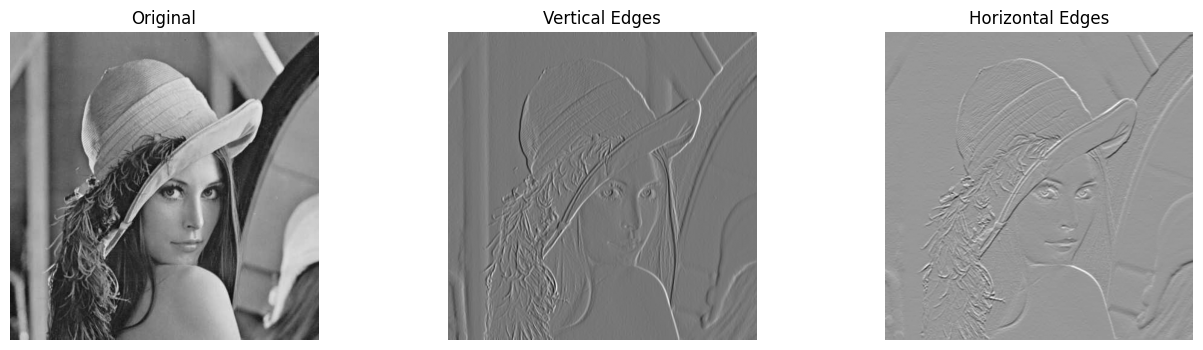

In [5]:
import requests, os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# Download a sample grayscale image (public-domain dog face)
url = "https://boofcv.org/images/f/fe/Original_lena512.jpg"
img_path = "lena.jpg"
if not os.path.exists(img_path):
    r = requests.get(url)
    with open(img_path, "wb") as f:
        f.write(r.content)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
print("Original shape:", img.shape)

# Define filters
vertical_filter = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
horizontal_filter = np.array([[1,1,1],[0,0,0],[-1,-1,-1]], dtype=np.float32)

# Convolve
vertical_edges   = convolve2d(img, vertical_filter, mode='same', boundary='symm')
horizontal_edges = convolve2d(img, horizontal_filter, mode='same', boundary='symm')

# Plot
fig, axs = plt.subplots(1, 3, figsize=(16,4))
axs[0].imshow(img, cmap='gray');               axs[0].set_title("Original");            axs[0].axis('off')
axs[1].imshow(vertical_edges, cmap='gray');    axs[1].set_title("Vertical Edges");      axs[1].axis('off')
axs[2].imshow(horizontal_edges, cmap='gray');  axs[2].set_title("Horizontal Edges");    axs[2].axis('off')
plt.show()

<a name="section1_3"></a>
### 2.3 Why CNNs vs. Dense Networks?

- **Dense**: Flatten images, ignoring local spatial structure, leading to a large parameter count.  
- **CNN**: Applies shared filters across the image, capturing edges & shapes more effectively with fewer parameters.

<a name="section1_4"></a>
### 2.4 Mini-Quiz #1

1. *Which operation do we use to detect edges in an image?*  
   A) **Convolution**  
   B) Fully connected layers  
   C) Batch normalization  

2. *True or False?* Convolution filters in a CNN are *hand-crafted* like in classical image processing.  
   **Answer**: False—CNN filters are *learned* during training.

<a name="section2"></a>
## **3. Part I: MNIST — Dense vs. CNN**

<a name="section2_1"></a>
### 3.1 Overview & Loading MNIST


In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32')/255.0
x_test  = x_test.astype('float32') /255.0

val_size = 5000
x_val = x_train[:val_size]
y_val = y_train[:val_size]
x_train = x_train[val_size:]
y_train = y_train[val_size:]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


<a name="section2_2"></a>
### 3.2 Build & Train a Dense Network (Baseline)

In [18]:
x_train_flat = x_train.reshape(-1, 784)
x_val_flat   = x_val.reshape(-1, 784)
x_test_flat  = x_test.reshape(-1, 784)

model_dense = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_dense.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_dense.fit(
    x_train_flat, y_train,
    epochs=5, batch_size=64,
    validation_data=(x_val_flat, y_val)
)

test_loss_dense, test_acc_dense = model_dense.evaluate(x_test_flat, y_test)
print("Dense Network Test Accuracy:", test_acc_dense)

Epoch 1/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8606 - loss: 0.5098 - val_accuracy: 0.9602 - val_loss: 0.1329
Epoch 2/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9621 - loss: 0.1289 - val_accuracy: 0.9724 - val_loss: 0.0922
Epoch 3/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9750 - loss: 0.0827 - val_accuracy: 0.9680 - val_loss: 0.1027
Epoch 4/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9802 - loss: 0.0658 - val_accuracy: 0.9708 - val_loss: 0.0888
Epoch 5/5
860/860 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9844 - loss: 0.0487 - val_accuracy: 0.9764 - val_loss: 0.0862
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9729 - loss: 0.0890
Dense Network Test Accuracy: 0.9747999906539917


<a name="section2_3"></a>
### 3.3 Build & Train a CNN on MNIST

In [ ]:
# Expand dims for CNN: (batch, 28, 28) -> (batch, 28, 28, 1)
x_train_cnn = np.expand_dims(x_train, axis=-1)
x_val_cnn   = np.expand_dims(x_val,   axis=-1)
x_test_cnn  = np.expand_dims(x_test,  axis=-1)

# 2. Define a CNN Model
model_cnn = tf.keras.Sequential([
    # input_shape ensures the model is built with known input
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

# 3. Train the Model
history_cnn = model_cnn.fit(
    x_train_cnn, y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_val_cnn, y_val)
)

# 4. Evaluate on Test Set
test_loss_cnn, test_acc_cnn = model_cnn.evaluate(x_test_cnn, y_test)
print("CNN Test Accuracy:", test_acc_cnn)

<a name="section2_4"></a>
### 3.4 Visualizing CNN Filters & Activations

In [25]:
# 5. One Forward Pass to fully define sub-model references
#   (Alternatively, training already calls the model, but
#    a quick predict here is safe if you run cells out of order)
_ = model_cnn.predict(x_train_cnn[:1])

# 6. Create a Sub-Model to get layer outputs
from tensorflow.keras.models import Model

# We'll visualize the outputs of the first 6 layers (2 conv + 2 pool + flatten + dense)
layer_outputs = [layer.output for layer in model_cnn.layers[:6]]
activation_model = Model(inputs=model_cnn.input, outputs=layer_outputs)

# 7. Predict on a sample test image
sample_img = x_test_cnn[:1]  # shape (1, 28, 28, 1)
activations = activation_model.predict(sample_img)

# 8. Visualize Activation Maps for each layer
for layer_idx, layer_activation in enumerate(activations):
    # layer_activation shape -> (1, height, width, channels)
    num_channels = layer_activation.shape[-1]
    n_cols = 8
    n_rows = math.ceil(num_channels / n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*1.5, n_rows*1.5))
    fig.suptitle(f"Layer {layer_idx} Activation Maps", fontsize=14)

    # If there's only 1 row, 'axes' might not be a 2D array
    axes = np.array(axes).reshape(n_rows, n_cols)

    for c in range(num_channels):
        row = c // n_cols
        col = c % n_cols

        # Single channel slice
        channel_image = layer_activation[0, :, :, c]

        axes[row, col].imshow(channel_image, cmap='gray')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


NameError: name 'activations' is not defined

<a name="section2_5"></a>
### 3.5 **Try-It-Yourself (TIY)**

Below are **code stubs** to guide your modifications:

**TIY #1: Changing Kernel Size**

In [ ]:
# === TIY #1: Insert Your Code Here ===
# Modify (3,3) to (5,5) in the first Conv2D below

model_cnn_tiy = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (# Insert Your Code Here ), activation='relu', input_shape=(28,28,1)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cnn_tiy.compile(...)
model_cnn_tiy.fit(...)

**TIY #2: Add/Remove a Conv Layer**

In [11]:
# === TIY #2: Insert Your Code Here ===
# You can add an extra Conv2D + MaxPooling2D block or remove one.
# Watch for overfitting or changes in accuracy & training time.

**TIY #3: Visualize Misclassifications**

In [12]:
# === TIY #3: Insert Your Code Here ===
# 1. preds = model_cnn.predict(x_test_cnn)
# 2. predicted_labels = np.argmax(preds, axis=1)
# 3. Compare with y_test, plot some misclassified digits.

<a name="section2_6"></a>
### 3.6 Mini-Quiz #2

1. *Why might a CNN outperform a dense network on MNIST?*  
   - **Answer**: Because convolution captures local pixel patterns with fewer parameters.

2. *Which layer typically follows a Conv2D layer to reduce spatial dimensions?*  
   - A) **MaxPooling2D**  
   - B) Dense  
   - C) Activation

<a name="section3"></a>
## **4. Part II: CIFAR-10 — Data Augmentation**

<a name="section3_1"></a>
### 4.1 Loading & Exploring CIFAR-10

In [14]:
(x_train_c10, y_train_c10), (x_test_c10, y_test_c10) = tf.keras.datasets.cifar10.load_data()
x_train_c10 = x_train_c10.astype('float32') / 255.0
x_test_c10  = x_test_c10.astype('float32')  / 255.0

val_size = 5000
x_val_c10 = x_train_c10[:val_size]
y_val_c10 = y_train_c10[:val_size]
x_train_c10 = x_train_c10[val_size:]
y_train_c10 = y_train_c10[val_size:]

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


**Classes**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck.

<a name="section3_1_1"></a>
### 4.1.1 **Data Augmentation Demonstration**

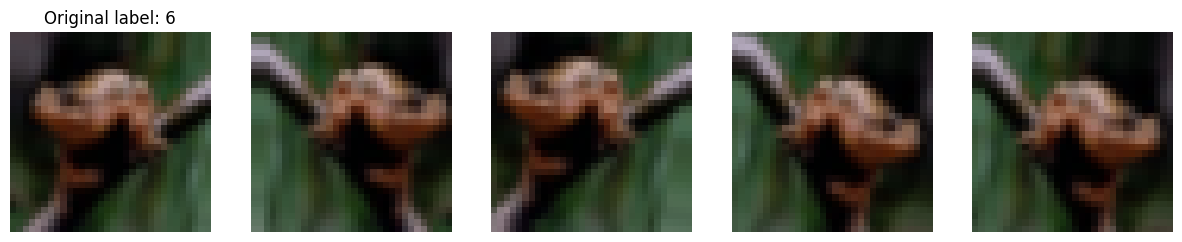

In [15]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

demo_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

sample_image_c10 = x_train_c10[0]
sample_label_c10 = y_train_c10[0]

demo_batch = np.expand_dims(sample_image_c10, axis=0)
demo_iter = demo_datagen.flow(demo_batch, batch_size=1)

fig, axs = plt.subplots(1, 5, figsize=(15,3))
for i in range(5):
    aug_img = next(demo_iter)[0].astype('float32')
    axs[i].imshow(aug_img)
    axs[i].axis('off')
axs[0].set_title(f"Original label: {sample_label_c10[0]}")
plt.show()

<a name="section3_2"></a>
### 4.2 CNN with Data Augmentation

In [16]:
train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator()

batch_size = 64
train_generator_c10 = train_datagen.flow(x_train_c10, y_train_c10, batch_size=batch_size)
val_generator_c10   = val_datagen.flow(x_val_c10, y_val_c10, batch_size=batch_size)

model_cifar = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

model_cifar.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_cifar = model_cifar.fit(
    train_generator_c10,
    steps_per_epoch=len(x_train_c10)//batch_size,
    epochs=10,
    validation_data=val_generator_c10,
    validation_steps=len(x_val_c10)//batch_size
)

test_loss_cifar, test_acc_cifar = model_cifar.evaluate(x_test_c10, y_test_c10, batch_size=batch_size)
print("CIFAR-10 Test Accuracy:", test_acc_cifar)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


703/703 ━━━━━━━━━━━━━━━━━━━━ 36s 45ms/step - accuracy: 0.2554 - loss: 2.0081 - val_accuracy: 0.4858 - val_loss: 1.4801
Epoch 2/10
  1/703 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5000 - loss: 1.6059

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 512us/step - accuracy: 0.5000 - loss: 1.6059 - val_accuracy: 0.4778 - val_loss: 1.4890
Epoch 3/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - accuracy: 0.4164 - loss: 1.5910 - val_accuracy: 0.5022 - val_loss: 1.3752
Epoch 4/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 0s 501us/step - accuracy: 0.4375 - loss: 1.5999 - val_accuracy: 0.5016 - val_loss: 1.3910
Epoch 5/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - accuracy: 0.4673 - loss: 1.4713 - val_accuracy: 0.5206 - val_loss: 1.3034
Epoch 6/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 853us/step - accuracy: 0.4688 - loss: 1.3986 - val_accuracy: 0.5347 - val_loss: 1.2780
Epoch 7/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.4985 - loss: 1.3899 - val_accuracy: 0.5781 - val_loss: 1.1751
Epoch 8/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 1s 904us/step - accuracy: 0.5312 - loss: 1.2033 - val_accuracy: 0.5871 - val_loss: 1.1546
Epoch 9/10
703/703 ━━━━━━━━━━━━━━━━━━━━ 41s 53ms/step - accuracy: 0.5127 - loss: 1.3492 - val_accurac

<a name="section3_3"></a>
### 4.3 **Try-It-Yourself (TIY)**

**TIY #4: Adjust Augmentations**

In [ ]:
# === TIY #4: Insert Your Code Here ===
# 1. Add brightness_range, zoom_range, or shear_range to train_datagen
# 2. Re-train, observe changes in final accuracy

**TIY #5: Confusion Matrix**

In [ ]:
```python
# === TIY #5: Insert Your Code Here ===
# 1. preds = model_cifar.predict(x_test_c10)
# 2. predicted_classes = np.argmax(preds, axis=1)
# 3. true_classes = y_test_c10.flatten()
# 4. Use sklearn.metrics.confusion_matrix, plot a heatmap

<a name="section3_4"></a>
### 4.4 Mini-Quiz #3

1. *Which function in Keras helps us apply random flips, shifts, or rotations to images?*  
   - A) ImageDataGenerator  
   - B) data.DataLoader  
   - C) flow_from_directory  

2. *True or False?* Data augmentation can reduce overfitting by providing diverse training samples.  
   - **Answer**: True

<a name="section4"></a>
## **5. Part III: Transfer Learning (Cats vs. Dogs)**

<a name="section4_1"></a>
### 5.1 Why Transfer Learning?
- Use a **pretrained** CNN on ImageNet.  
- **Feature Extraction**: Freeze base layers.  
- **Fine-Tuning**: Unfreeze top layers to adapt them to your dataset.

<a name="section4_2"></a>
### 5.2 Loading Cats vs. Dogs from TFDS

In [26]:
import tensorflow_datasets as tfds

(ds_full, ds_info) = tfds.load('cats_vs_dogs', with_info=True, as_supervised=True)
ds_train = tfds.load('cats_vs_dogs', split='train[:80%]', as_supervised=True)
ds_val   = tfds.load('cats_vs_dogs', split='train[80%:90%]', as_supervised=True)
ds_test  = tfds.load('cats_vs_dogs', split='train[90%:]',   as_supervised=True)

def format_image(image, label):
    image = tf.image.resize(image, (224,224))
    image = image/255.0
    return image, label

batch_size = 32
ds_train = ds_train.map(format_image).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_val   = ds_val.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(format_image).batch(batch_size).prefetch(tf.data.AUTOTUNE)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...:   0%|          | 0/23262 [00:00<?, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.I217QM_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


<a name="section4_3"></a>
### 5.3 Feature Extraction & Fine-Tuning

In [ ]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
for layer in base_model.layers:
    layer.trainable = False

model_tl = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model_tl.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tl.fit(ds_train, epochs=5, validation_data=ds_val)

# Fine-tuning
for layer in base_model.layers[-4:]:
    layer.trainable = True

model_tl.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='binary_crossentropy', metrics=['accuracy'])
model_tl.fit(ds_train, epochs=5, validation_data=ds_val)

test_loss, test_acc = model_tl.evaluate(ds_test)
print("Cats vs Dogs Test Accuracy:", test_acc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 216ms/step - accuracy: 0.8471 - loss: 0.4586 - val_accuracy: 0.9230 - val_loss: 0.1791
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 111s 186ms/step - accuracy: 0.9166 - loss: 0.2037 - val_accuracy: 0.9209 - val_loss: 0.1813
Epoch 3/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 109s 185ms/step - accuracy: 0.9301 - loss: 0.1743 - val_accuracy: 0.9299 - val_loss: 0.1733
Epoch 4/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 186ms/step - accuracy: 0.9353 - loss: 0.1569 - val_accuracy: 0.9282 - val_loss: 0.1656
Epoch 5/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 109s 185ms/step - accuracy: 0.9363 - loss: 0.1473 - val_accuracy: 0.9299 - val_loss: 0.1627
Epoch 1/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 142s 230ms/step - accuracy: 0.9568 - loss: 0.1068 - val_accuracy: 0.9445 - val_loss: 0.1599
Epoch 2/5
582/582 ━━━━━━━━━━━━━━━━━━━━ 131s 223ms/step - accuracy: 0.9755 - loss: 0.0619 - val_accuracy: 0.9506 - val_loss: 0.1426
Epoch 3/5
582/582 ━━━━━━━━━━━━━━

<a name="section4_4"></a>
### 5.4 **Try-It-Yourself (TIY)**


**TIY #6: Freeze vs. Unfreeze**

In [ ]:
# === TIY #6: Insert Your Code Here ===
# 1. Freeze entire base -> train 3-5 epochs
# 2. Unfreeze last 4 layers -> smaller LR -> re-train
# 3. Compare final accuracy

**TIY #7: Change Pretrained Model**

In [ ]:
# === TIY #7: Insert Your Code Here ===
# from tensorflow.keras.applications import ResNet50 or MobileNetV2
# base_model_2 = ResNet50(...)
# Compare performance vs. VGG16

**TIY #8: Visualize Misclassifications**

In [ ]:
# === TIY #8: Insert Your Code Here ===
# 1. preds = model_tl.predict(ds_test)
# 2. threshold -> 0 or 1
# 3. gather true_labels, compare, plot misclassified cat/dog images

<a name="section4_5"></a>
### 5.5 Mini-Quiz #4

1. *When we unfreeze top layers in transfer learning, we should typically?*  
   - A) **Use a smaller learning rate**  
   - B) Use a bigger learning rate  
   - C) Use the same learning rate  

2. *True or False?* Feature extraction alone can’t achieve high accuracy.  
   - **Answer**: False—often it’s good enough, but fine-tuning can improve results further.

<a name="section5"></a>
## **6. Optional: TensorBoard Demonstration**

**Why**: Visualizing training/validation curves can help debug or monitor training progress.

In [ ]:
from tensorflow.keras.callbacks import TensorBoard
import datetime

log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# Example usage in model_cifar or model_cnn:
model_cnn.fit(
    x_train_cnn, y_train,
    epochs=5, batch_size=64,
    validation_data=(x_val_cnn, y_val),
    callbacks=[tensorboard_callback]
)

# In Colab:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit

<a name="section6"></a>
## **7. Optional: Grad-CAM Demonstration**

**Goal**: See *where* the CNN “looked” in an image.

In [ ]:
import numpy as np
import matplotlib.cm as cm
import cv2

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs],
        [model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    heatmap = np.maximum(heatmap, 0) / (np.max(heatmap)+1e-8)
    return heatmap.numpy()

# Then overlay heatmap on original image, see which regions influenced the classification most.

<a name="section7"></a>
## **8. Hyperparameter Tuning Tips**

1. **Manual**: Try different batch sizes, learning rates, kernel sizes. Document results.  
2. **Keras Tuner**:  
   ```python
   # pip install keras-tuner
   # Example usage of a tuner with different hyperparameters.
   ```
3. **Observe** if bigger networks or more layers actually help or cause overfitting.

<a name="section8"></a>
## **9. Reflection & Summary**

**Students Learned**:
1. How **convolutions** detect edges and shapes (manual filter demo).  
2. **Dense vs. CNN** on MNIST, seeing CNN’s advantage.  
3. **Data Augmentation** on CIFAR-10 (demonstration + training).  
4. **Transfer Learning** for Cats vs. Dogs, with feature extraction & optional fine-tuning.  
5. **TensorBoard** for monitoring, **Grad-CAM** for interpretability, and **basic hyperparameter tuning** tips.

<a name="section9"></a>
## **10. Additional Best Practices**

- **Experiment Logging**: Keep a record (spreadsheet/MLflow) of changes & results.  
- **Early Stopping**: If validation loss stops improving, halt training.  
- **Data Splits**: Always maintain a separate test set to avoid data leakage.


<a name="section10"></a>
## **11. Common Pitfalls & Solutions**

1. **Overfitting**: More augmentation, dropout, or smaller architecture.  
2. **Shape Errors**: Always confirm `(batch, height, width, channels)`.  
3. **Learning Rate**: If stuck, lower or raise LR, or try a scheduler.  
4. **Data Leakage**: Strictly separate train/val/test.

<a name="section11"></a>
## **12. Wrap-Up & Further Resources**

**Congratulations**:  
- You’ve completed a **full journey**: from *manual convolution* to *CNN training* on MNIST/CIFAR-10, then *transfer learning* for Cats vs. Dogs.  
- **Try** adding more advanced augmentation (RandAugment, AutoAugment), or **Grad-CAM** for model interpretability.  
- Tinker with **hyperparameter tuning** for even better results.

### **Further Resources**

1. [Keras Documentation](https://keras.io/)  
2. [TensorFlow Tutorials](https://www.tensorflow.org/tutorials)  
3. [Stanford CS231n](http://cs231n.stanford.edu/)  
4. [Andrew Ng’s Deep Learning Specialization](https://www.coursera.org/specializations/deep-learning)